# Graph statistics

In [1]:
DATASET = "STF_HC_Voto_Relatorio"
# DATASET = "IMDB"
DATASET_PATH = f"../data/datasets/{DATASET}/train/interim"

In [2]:
import networkx as nx

def print_graph_statistics_multidigraph(G: nx.MultiDiGraph) -> tuple:
    """
    Print graph-level statistics for a given NetworkX MultiDiGraph.
    Handles directed multigraphs appropriately.

    Parameters:
    - G (nx.MultiDiGraph): A NetworkX MultiDiGraph object

    Returns:
    - tuple: A set of graph metrics including:
        (num_nodes, num_edges, avg_degree, density,
         avg_clustering, diameter, avg_path_length,
         assortativity, num_connected_components)
    """
    # Basic stats
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes > 0 else 0
    density = nx.density(G)

    # Convert to a simple directed and undirected graph
    simple_digraph = nx.DiGraph(G)
    undirected_graph = simple_digraph.to_undirected()

    # Connectivity checks
    if nx.is_weakly_connected(simple_digraph):
        try:
            diameter = nx.diameter(undirected_graph)
            avg_path_length = nx.average_shortest_path_length(simple_digraph)
        except nx.NetworkXError:
            diameter = "N/A"
            avg_path_length = "N/A"
    else:
        diameter = "N/A"
        avg_path_length = "N/A"

    # Clustering
    try:
        avg_clustering = nx.average_clustering(undirected_graph)
    except Exception:
        avg_clustering = 0.0

    # Assortativity (degree correlation)
    try:
        assortativity = nx.degree_pearson_correlation_coefficient(undirected_graph)
    except Exception:
        assortativity = float('nan')

    # Connected components
    try:
        num_components = nx.number_connected_components(undirected_graph)
    except Exception:
        num_components = -1

    # Return stats as tuple (can print or save)
    return (
        num_nodes, num_edges, avg_degree, density,
        avg_clustering, diameter, avg_path_length,
        assortativity, num_components
    )




In [3]:
import tqdm
import torch
import networkx as nx
from pathlib import Path

# Load graph paths
stored_graph_paths = Path(DATASET_PATH).glob("*.pt")
stored_graph_paths = list(stored_graph_paths)

# Track max graph info
max_num_nodes = 0
max_num_edges = 0
doc_max_nodes = None
label_max_nodes = None

# Collect global metrics
num_nodes_global = []
num_edges_global = []
avg_degrees = []
densities = []
clusterings = []
diameters = []
avg_path_lengths = []
assortativities = []
num_components_list = []

for graph_data_path in tqdm.tqdm(stored_graph_paths, desc="Analyzing graphs"):
    doc_name, label, graph_nx = torch.load(graph_data_path)

    (
        num_nodes, num_edges, avg_degree, density,
        avg_clustering, diameter, avg_path_length,
        assortativity, num_components
    ) = print_graph_statistics_multidigraph(graph_nx)

    if num_nodes > max_num_nodes:
        max_num_nodes = num_nodes
        doc_max_nodes = doc_name
        label_max_nodes = label
        max_num_edges = num_edges

    # Store stats
    num_nodes_global.append(num_nodes)
    num_edges_global.append(num_edges)
    avg_degrees.append(avg_degree)
    densities.append(density)
    clusterings.append(avg_clustering)
    diameters.append(diameter)
    avg_path_lengths.append(avg_path_length)
    assortativities.append(assortativity)
    num_components_list.append(num_components)

# Helper to safely average or report N/A
def safe_avg(values):
    valid_values = [v for v in values if isinstance(v, (int, float))]
    return sum(valid_values) / len(valid_values) if valid_values else "N/A"

# Final summary
print(f"\n📊 Graph Summary:")
print(f"Max Nodes: {max_num_nodes} (Doc: {doc_max_nodes}, Label: {label_max_nodes})")
print(f"Avg Nodes: {safe_avg(num_nodes_global):.2f}")
print(f"Avg Edges: {safe_avg(num_edges_global):.2f}")
print(f"Avg Degree: {safe_avg(avg_degrees):.2f}")
print(f"Avg Density: {safe_avg(densities):.4f}")
print(f"Avg Clustering: {safe_avg(clusterings):.4f}")
print(f"Avg Diameter: {safe_avg(diameters)}")
print(f"Avg Path Length: {safe_avg(avg_path_lengths)}")
print(f"Avg Assortativity: {safe_avg(assortativities):.4f}")
print(f"Avg Num Connected Components: {safe_avg(num_components_list):.2f}")


Analyzing graphs:   0%|          | 0/1228 [00:00<?, ?it/s]/tmp/ipykernel_47048/433867451.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  doc_name, label, graph_nx = tor


📊 Graph Summary:
Max Nodes: 1000 (Doc: 1651.txt, Label: Solto)
Avg Nodes: 414.35
Avg Edges: 619.29
Avg Degree: 2.87
Avg Density: 0.0038
Avg Clustering: 0.0229
Avg Diameter: N/A
Avg Path Length: N/A
Avg Assortativity: -0.0437
Avg Num Connected Components: 7.19


In [4]:
import pandas as pd

# Create DataFrame with all tracked metrics
df = pd.DataFrame({
    "nodes": num_nodes_global,
    "edges": num_edges_global,
    "avg_degree": avg_degrees,
    "density": densities,
    "clustering": clusterings,
    "diameter": diameters,
    "path_length": avg_path_lengths,
    "assortativity": assortativities,
    "components": num_components_list
})

# Optional: Convert non-numeric entries to NaN for numeric stats
df = df.apply(pd.to_numeric, errors='coerce')

# Describe with custom percentiles
desc = df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

# Round for readability
desc = desc.round(4)

# Print summary
print("\n📊 Detailed Graph Statistics:")
desc



📊 Detailed Graph Statistics:


,nodes,edges,avg_degree,density,clustering,diameter,path_length,assortativity,components
count,1228.0000,1228.0000,1228.0000,1228.0000,1228.0000,0.0,0.0,1228.0000,1228.0000
mean,414.3493,619.2940,2.8658,0.0038,0.0229,NaN,NaN,-0.0437,7.1873
std,161.4698,371.0548,0.4391,0.0011,0.0099,NaN,NaN,0.0586,3.0108
min,128.0000,152.0000,2.2550,0.0017,0.0000,NaN,NaN,-0.2708,1.0000
10%,272.0000,351.7000,2.4676,0.0026,0.0115,NaN,NaN,-0.1144,4.0000
25%,317.0000,418.0000,2.6045,0.0031,0.0160,NaN,NaN,-0.0852,5.0000
50%,376.0000,511.0000,2.7936,0.0037,0.0219,NaN,NaN,-0.0444,7.0000
75%,458.0000,665.0000,2.9931,0.0043,0.0284,NaN,NaN,-0.0032,9.0000
90%,620.0000,1004.0000,3.3287,0.0051,0.0358,NaN,NaN,0.0287,11.0000
max,1000.0000,4454.0000,8.9080,0.0096,0.0729,NaN,NaN,0.2243,22.0000


(array([ 35., 208., 445., 278., 105.,  49.,  43.,  17.,  10.,  38.]),
 array([ 128. ,  215.2,  302.4,  389.6,  476.8,  564. ,  651.2,  738.4,
         825.6,  912.8, 1000. ]),
 <BarContainer object of 10 artists>)

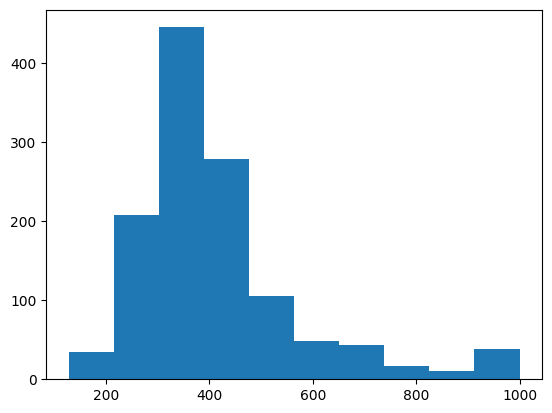

In [6]:
from matplotlib import pyplot as plt

plt.hist(num_nodes_global)

(array([796., 311.,  71.,  25.,  18.,   3.,   3.,   0.,   0.,   1.]),
 array([ 152. ,  582.2, 1012.4, 1442.6, 1872.8, 2303. , 2733.2, 3163.4,
        3593.6, 4023.8, 4454. ]),
 <BarContainer object of 10 artists>)

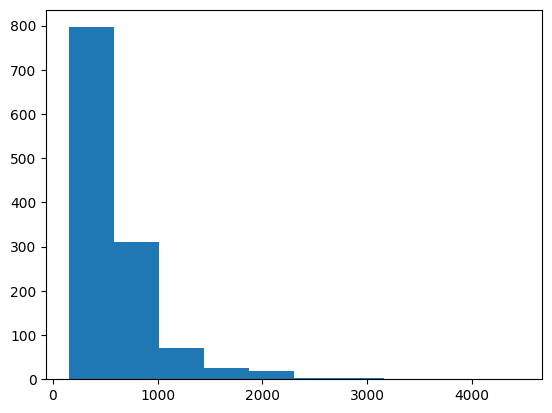

In [7]:
plt.hist(num_edges_global)